In [3]:
pip install pyserial

Note: you may need to restart the kernel to use updated packages.


In [18]:
import serial
import numpy as np
import time

class PicoController:
    def __init__(self, sample_rate_hz, transmit, receive, buf_size,
                 port='/dev/tty.usbmodem21201', baud=115200):

        self.ser = serial.Serial(port, baud, timeout=5)

        time.sleep(0.2)
        self.ser.reset_input_buffer()

        # ---- INIT ----
        cmd = f"I {sample_rate_hz} {int(transmit)} {int(receive)} {buf_size}\n"
        self.ser.write(cmd.encode())

        resp = self._readline_blocking("OK")

        parts = resp.split()
        self.actual_freq = float(parts[1])
        self.actual_buf_size = int(parts[2])

        print(f"[Pico] Freq: {self.actual_freq} Hz | Buffer: {self.actual_buf_size}")

    # =========================================================
    # Core helpers
    # =========================================================
    def _readline_blocking(self, expect=None):
        """Read full line, retry until valid"""
        while True:
            line = self.ser.readline().decode(errors="ignore").strip()
            if not line:
                continue
            if expect is None or line.startswith(expect):
                return line

    def _read_exact_bytes(self, n_bytes):
        """Read exactly N bytes (critical for large DATA)"""
        buf = b""
        while len(buf) < n_bytes:
            chunk = self.ser.read(n_bytes - len(buf))
            if not chunk:
                raise RuntimeError("Timeout while reading data")
            buf += chunk
        return buf

    # =========================================================
    # GET SAMPLES
    # =========================================================
    def getsamples(self, n_samples):
        if n_samples > self.actual_buf_size:
            raise ValueError("Requested more than buffer size")

        self.ser.write(f"G {n_samples}\n".encode())

        # First read "DATA:"
        header = self.ser.read(5).decode()
        if header != "DATA:":
            raise RuntimeError(f"Protocol error, got: {header}")

        # Now read exact payload length
        expected_chars = n_samples * 4
        payload = self._read_exact_bytes(expected_chars).decode()

        # Read trailing newline
        self.ser.read(1)

        # Convert to numpy
        data = np.frombuffer(
            bytes.fromhex(payload),
            dtype='>u2'   # big-endian unsigned 16-bit
        )

        return data
        # map from [0, 65535] → [-1, 1]
        # normalized_data = (data / 65535.0) * 2.0 - 1.0
        # return normalized_data

    # =========================================================
    # PUT SAMPLES
    # =========================================================
    def putsamples(self, data):
        # map from [-1, 1] → [0, 65535]
        data = ((data + 1.0) * 0.5 * 65535)
        data = np.clip(data, 0, 65535).astype(np.uint16)

        hex_str = " ".join(f"{x:04x}" for x in data)
        cmd = f"P {len(data)} {hex_str}\n"
        self.ser.write(cmd.encode())

        resp = self._readline_blocking("OK")
        return resp

    # =========================================================
    # GET BUFFER LENGTH
    # =========================================================
    def get_buflen(self):
        self.ser.write(b"L\n")
        resp = self._readline_blocking()
        return int(resp)

    # =========================================================
    # RESET
    # =========================================================
    def reset(self):
        self.ser.write(b"X\n")
        resp = self._readline_blocking("RESET")
        return resp

    def close(self):
        if self.ser.is_open:
            self.reset()
            self.ser.close()


if __name__ == "__main__":
    # pico = PicoController(
    #     sample_rate_hz=10_000_000,
    #     transmit=True,
    #     receive=False,
    #     buf_size=100000,
    #     port='/dev/tty.usbmodem21301'
    # )
    # f = 1              # Frequency (cycles per second)
    # A = 1              # Amplitude (height of the wave)
    # fs = 10000000           # Sampling rate (points per second)
    # duration = 2       # Total time in seconds
    
    # # 2. Generate Time and Wave Data
    # # Create a time array from 0 to 'duration'
    # t = np.linspace(0, duration, 100000)
    
    # # Calculate the sine wave using the formula: y = A * sin(2 * pi * f * t)
    # y = A * np.sin(2 * np.pi * f * t)
    # plt.plot(t, y)
    # samples = pico.putsamples(y)


    # pico.reset()

    pico = PicoController(
        sample_rate_hz=1_000_000,
        transmit=False,
        receive=True,
        buf_size=10000,
        port='/dev/tty.usbmodem1301'
    )

    # wave = np.array([-1, 1] * 5000)
    # samples = pico.putsamples(wave)

    samples = pico.getsamples(5000)

    # pico.reset()

[Pico] Freq: 1000000.0 Hz | Buffer: 10000


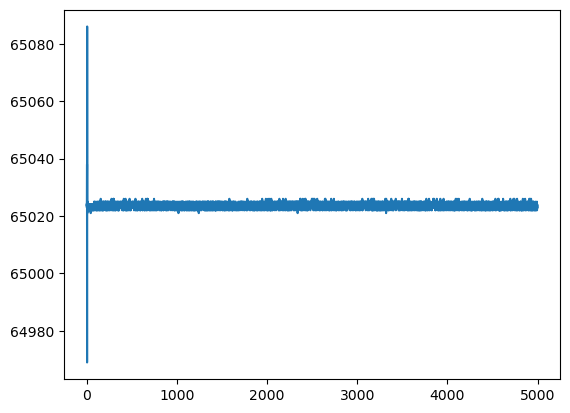

In [20]:
import matplotlib.pyplot as plt
x = range(len(samples))
plt.plot(x, samples)

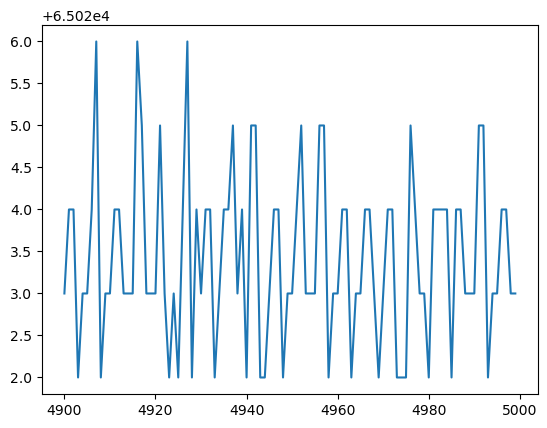

In [22]:
import matplotlib.pyplot as plt
x = range(len(samples))
plt.plot(x[-100:], samples[-100:])